## Imports

In [ ]:
from __future__ import annotations
import os
import re
import seaborn as sns
import json
import matplotlib.pyplot as plt
import math
import hashlib
import random
from collections import Counter
from pathlib import Path
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider

token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)
azure_client = AzureOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_ad_token_provider=token_provider
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Systeem: Modellen worden geladen op device: {device}")


Systeem: Modellen worden geladen op device: cpu


## Chunking

In [ ]:
HEADER_ALIASES_BY_KIND = {
    "vakantieverhuur": {
        "chunk_bezwaar": {"bezwaren", "de bezwaren", "uw bezwaar", "uw bezwaren", "bezwaar", "tegen het besluit", "bezwaargronden", "gronden van bezwaar", "standpunt bezwaarmaker", "bezwaarschrift"},
        "chunk_hoorzitting": {"hoorzitting", "horen", "telefonisch horen", "telefonisch contact", "digitale hoorzitting", "informele hoorzitting", "informeel overleg", "hoorverslag", "gesprek", "telefonisch verslag"},
        "chunk_wetten": {"juridisch kader", "wet- en regelgeving", "wet en regelgeving", "wettelijk kader", "toepasselijke regels", "bijlagen wettelijke kader"},
        "chunk_uitleg": {"beoordeling bezwaarschrift", "overwegingen", "motivering", "beoordeling", "toetsingskader", "advies", "conclusie", "slotsom", "beslissing", "aanleiding", "inleiding", "feiten", "ontvankelijkheid", "procesverloop", "beslissing op bezwaar", "overwegingen en beoordeling bezwaar", "dit betekent voor u", "wij wijzen u verder", "overwegingen bij bezwaren en toelichting op het besluit"},
    },
    "woonruimteverdeling": {
        "chunk_bezwaar": {"bezwaren", "de bezwaren", "uw bezwaar", "uw bezwaren", "bezwaar", "tegen het besluit", "bezwaargronden", "gronden van bezwaar", "standpunt bezwaarmaker", "bezwaarschrift"},
        "chunk_hoorzitting": {"hoorzitting", "horen", "telefonisch horen", "telefonisch contact", "digitale hoorzitting", "informele hoorzitting", "informeel overleg", "hoorverslag", "gesprek", "telefonisch verslag"},
        "chunk_wetten": {"juridisch kader", "wet- en regelgeving", "wet en regelgeving", "wettelijk kader", "toepasselijke regels", "bijlagen wettelijke kader"},
        "chunk_uitleg": {"beoordeling bezwaarschrift", "overwegingen", "motivering", "beoordeling", "toetsingskader", "advies", "conclusie", "slotsom", "beslissing", "aanleiding", "inleiding", "feiten", "ontvankelijkheid", "procesverloop", "beslissing op bezwaar", "overwegingen en beoordeling bezwaar", "dit betekent voor u", "wij wijzen u verder", "overwegingen bij bezwaren en toelichting op het besluit"},
    }
}

IGNORE_HEADER_PATTERNS = [
    r"^met vriendelijke groet", r"^hoogachtend", r"^stuur uw beroepschrift naar", r"^rechtbank", r"^directeur\b.*", r"^gemeente amsterdam\b.*", 
    r"^[^\n]*gemeente\s+amsterdam(?:\s+en\s+\w+)?[^\n]*", r"^in uw beroepschrift moet staan", r"^octopus[-\s]*nummers?:", r"^zaak[-\s]*nummer", 
    r"^ten aanzien van", r"^gericht tegen", r"^ingediend door", r"^betreft:", r"^dhr\.", r"^mevr\.", r"^\[naam\]", r"^mevrouw\b.*", r"^meneer\b.*", r"^de heer\b.*" 
]

def _compute_md5(text: str) -> str: 
    return hashlib.md5((text or "").encode("utf-8")).hexdigest()

def _normalize_text_for_hash(text: str) -> str: 
    return "" if pd.isna(text) else re.sub(r"[^\S\n]+", " ", str(text)).strip()

def _detect_text_column(df: pd.DataFrame, preferred: str = "") -> str:
    if preferred and preferred in df.columns: return preferred
    for c in ["geanonimiseerd_doc_inhoud", "Legal_Text", "Document inhoud", "text", "tekst"]:
        if c in df.columns: return c
    raise ValueError("Geen geldige tekstkolom gevonden in het DataFrame.")

def _restore_missing_newlines(text: str) -> str:
    if pd.isna(text): return ""
    flat_headers = ["Beslissing op bezwaar", "Overwegingen en beoordeling bezwaar", "Overwegingen en beoordeling", "Overwegingen bij bezwaren en toelichting op het besluit", "Dit betekent voor u:", "Beroep", "Vragen?", "Met vriendelijke groet,", "Huisvestingswet 2014", "Huisvestingsverordening Amsterdam 2020", "Huisvestingsverordening Amsterdam 2024", "Nadere Regels Huisvestingsverordening", "Algemene wet bestuursrecht", "Bezwaren", "Hoorzitting", "Telefonisch verslag", "Wettelijk kader", "Wet- en regelgeving", "Toepasselijke regels", "Zorgregeling"]
    for h in flat_headers: text = re.sub(rf"\s*({re.escape(h)})\s*", r"\n\1\n", text)
    return re.sub(r"\n{2,}", "\n\n", text).strip()

def _normalize_header_key(line: str) -> str:
    t = re.sub(r"^(?:\d+|[IVXLC]+)[\.\)\s,-]+", "", (line or "").strip(), flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", re.sub(r"[\s:;?!\.]+$", "", t)).strip().lower()

def _alias_map_for_kind(kind: str, section_sets: dict[str, set[str]]) -> dict[str, str]:
    alias_map = {}
    for section, names in (section_sets or {}).items():
        for name in names:
            norm = _normalize_header_key(name)
            if norm: alias_map[norm] = section
    return alias_map

def _is_ignored_header_line(line: str) -> bool: 
    return not (line or "").strip() or any(re.match(pat, (line or "").strip(), flags=re.IGNORECASE) for pat in IGNORE_HEADER_PATTERNS)

def _looks_like_header(line: str) -> bool:
    t = (line or "").strip()
    if not t: return False
    if re.match(r"^[-*•\u2022\u2013\u2014]", t): 
        return False
        
    candidate = re.sub(r"^(?:\d+|[IVXLC]+)[\.\)\s-]+", "", t, flags=re.IGNORECASE).strip().rstrip(":").strip()
    if not candidate or len(candidate) > 120: return False
    
    first_char = re.sub(r"[^a-zA-Z0-9]", "", candidate)
    if first_char and not first_char[0].isupper() and not first_char[0].isdigit():
        return False

    words = re.findall(r"[A-Za-z\u00C0-\u00FF]+", candidate)
    if len(words) > 10: return False  
    if t.endswith(":"):
        if len(words) > 4: 
            return False 
        return True
        
    if candidate.isupper(): return True
    if all(w[:1].isupper() for w in words) and not re.search(r"[\.!?]", candidate): return True
    return len(words) <= 7 and len(candidate) <= 70 and not re.search(r"[\.!?]", candidate)

def _is_header_line(line: str, header_to_section: Optional[dict]) -> bool:
    if _is_ignored_header_line(line): return False
    if header_to_section and _normalize_header_key(line) in header_to_section: return True
    return _looks_like_header(line)

def _guess_section_for_header(norm: str) -> Optional[str]:
    if "bezwaar" in norm and "beslissing" not in norm and "beoordeling" not in norm: return "chunk_bezwaar"
    if any(k in norm for k in ("wet", "regel", "juridisch", "kader", "bijlage")): return "chunk_wetten"
    if any(k in norm for k in ("hoor", "gesprek", "telefonisch", "mondeling", "verslag", "contact")): return "chunk_hoorzitting"
    if any(k in norm for k in ("overweging", "beoordeling", "conclusie", "besluit", "beslissing", "betekent", "wijzen", "feit")): return "chunk_uitleg"
    return None

def _chunk_document_by_short_titles(document: str, header_to_section: Optional[dict] = None) -> list[str]:
    paragraphs = (document or "").split("\n")
    chunks, current_chunk = [], []
    for p in paragraphs:
        if p.strip() == "" or _is_ignored_header_line(p):
            current_chunk.append(p)
            continue
        if _is_header_line(p, header_to_section):
            if current_chunk: chunks.append("\n".join(current_chunk))
            current_chunk = [p]
        else: current_chunk.append(p)
    if current_chunk: chunks.append("\n".join(current_chunk))
    return chunks

def _derive_paragraphs_from_chunks(chunks: list[str], section_sets: dict[str, set[str]], fallback_key: str, kind: str) -> dict:
    sections = {k: [] for k in section_sets.keys()}
    sections.setdefault("paragraaf_overig", [])
    header_to_section = _alias_map_for_kind(kind, section_sets)
    current_target = fallback_key

    for chunk in chunks:
        lines = chunk.split("\n")
        if not lines: continue
        header_idx = next((i for i, v in enumerate(lines) if v.strip() and not _is_ignored_header_line(v)), None)
        
        if header_idx is not None:
            header_line = lines[header_idx]
            header = _normalize_header_key(header_line)
            if _is_header_line(header_line, header_to_section):
                if kind == "vakantieverhuur":
                    current_target = header_to_section.get(header) or _guess_section_for_header(header) or fallback_key
                else: 
                    target = header_to_section.get(header) or _guess_section_for_header(header) or fallback_key
                    current_target = target
            else:
                if "maakte u bezwaar" in header_line.lower() or "tegen het besluit" in header_line.lower():
                    current_target = "chunk_bezwaar"
                elif kind == "woonruimteverdeling":
                    current_target = fallback_key

        content = "\n".join(lines)
        if content.strip(): sections[current_target].append(content)

    return {c: "\n".join(sections.get(c, [])).strip() for c in ["chunk_bezwaar", "chunk_hoorzitting", "chunk_uitleg", "chunk_wetten"]}

def chunk_housing_dataframe(df: pd.DataFrame, kind: str, text_column: str = "", dedupe: bool = True) -> pd.DataFrame:
    df_processed = df.copy()
    source_col = _detect_text_column(df_processed, preferred=text_column)
    df_processed["geanonimiseerd_doc_inhoud"] = df_processed[source_col].fillna("").apply(_restore_missing_newlines)

    if dedupe:
        df_processed["__doc_hash"] = df_processed["geanonimiseerd_doc_inhoud"].apply(_normalize_text_for_hash).apply(_compute_md5)
        df_processed = df_processed.drop_duplicates(subset=["__doc_hash"], keep="first").drop(columns=["__doc_hash"])

    section_sets = HEADER_ALIASES_BY_KIND[kind]
    derived = df_processed["geanonimiseerd_doc_inhoud"].apply(lambda t: _derive_paragraphs_from_chunks(_chunk_document_by_short_titles(t, _alias_map_for_kind(kind, section_sets)), section_sets, "chunk_uitleg", kind)).apply(pd.Series)
    
    for c in derived.columns: df_processed[c] = derived[c].fillna("")
    return df_processed

## Dataloading

In [ ]:
def subtype_v(subject):
    if 'verhuurvergunning' in str(subject).lower(): return 'Rental Permit'
    if 'bed&breakfast' in str(subject).lower(): return 'B&B'
    if 'verbodsgebieden' in str(subject).lower(): return 'Prohibited Areas'
    return 'Other'

def subtype_wrv(subject):
    s = str(subject).lower()
    if 'afbouw' in s: return 'Total Point Reset' if 'alle punten' in s else 'Point Sanction (Reduction)'
    if 'afwijzing' in s or 'rejection' in s:
        if 'jongeren' in s: return 'Rejection: Youth Category'
        if 'gezin' in s: return 'Rejection: Family Category'
        return 'Application Rejection'
    if 'situatiepunten' in s and 'start' in s: return 'Allocation: Start & Situation Points'
    if 'situatiepunten' in s: return 'Allocation: Situation Points'
    if 'startpunten' in s: return 'Allocation: Starting Points'
    return 'Other / Miscellaneous'

# --- Vacation Rental ---
print("Laden van vakantieverhuur data...")
df_all_v = pd.read_csv(r'Data\vakantieverhuur.csv', sep=';', on_bad_lines='warn', engine='python', encoding='cp1252')
df_all_v.columns = df_all_v.columns.str.strip()

df_v_training = df_all_v.sample(frac=0.8, random_state=42).copy()
df_v_testing = df_all_v.drop(df_v_training.index).copy()

df_v_training['Onderwerp'] = df_v_training['Onderwerp'].apply(subtype_v)
df_v_training.rename(columns={'Onderwerp': 'Subtype', 'geanonimiseerd_doc_inhoud': 'Legal_Text', 'Octopus zaaknummer': 'case_id', 'Dictum': 'dictum'}, inplace=True)
df_v_testing['Onderwerp'] = df_v_testing['Onderwerp'].apply(subtype_v)
df_v_testing.rename(columns={'Onderwerp': 'Subtype', 'geanonimiseerd_doc_inhoud': 'Legal_Text', 'Octopus zaaknummer': 'case_id', 'Dictum': 'dictum'}, inplace=True)

df_all_wrv = pd.read_csv(r'Data\WRV_bezwaren_.csv', sep=';', on_bad_lines='warn', engine='python', encoding='cp1252')
df_all_wrv.columns = df_all_wrv.columns.str.strip()

df_wrv_training = df_all_wrv.sample(frac=0.8, random_state=42).copy()
df_wrv_testing = df_all_wrv.drop(df_wrv_training.index).copy()

df_wrv_training['Onderwerp'] = df_wrv_training['Onderwerp'].apply(subtype_wrv)
df_wrv_training.rename(columns={'Onderwerp': 'Subtype', 'geanonimiseerd_doc_inhoud': 'Legal_Text', 'Octopus zaaknummer': 'case_id', 'Dictum': 'dictum'}, inplace=True)
df_wrv_testing['Onderwerp'] = df_wrv_testing['Onderwerp'].apply(subtype_wrv)
df_wrv_testing.rename(columns={'Onderwerp': 'Subtype', 'geanonimiseerd_doc_inhoud': 'Legal_Text', 'Octopus zaaknummer': 'case_id', 'Dictum': 'dictum'}, inplace=True)

for df in [df_v_training, df_v_testing, df_wrv_training, df_wrv_testing]:
    df["dictum"] = df["dictum"].fillna("").str.lower()

print("Uitvoeren van de Chunking Engine op alle datasets...")
df_v_training = chunk_housing_dataframe(df_v_training, kind="vakantieverhuur", text_column="Legal_Text", dedupe=False)
df_v_testing = chunk_housing_dataframe(df_v_testing, kind="vakantieverhuur", text_column="Legal_Text", dedupe=False)
df_wrv_training = chunk_housing_dataframe(df_wrv_training, kind="woonruimteverdeling", text_column="Legal_Text", dedupe=False)
df_wrv_testing = chunk_housing_dataframe(df_wrv_testing, kind="woonruimteverdeling", text_column="Legal_Text", dedupe=False)
print("Data succesvol geladen en gechunked!")

Laden van vakantieverhuur data...
Laden van woonruimteverdeling data...
Uitvoeren van de Chunking Engine op alle datasets...
Data succesvol geladen en gechunked!


In [ ]:
df = df_all_wrv.copy()
case_id = "WO.23.004695.001"
case_row = df[df["Octopus zaaknummer"] == case_id]

if case_row.empty:
    print(f"Zaak ID {case_id} niet gevonden.")

else:
    raw_text = case_row.iloc[0][_detect_text_column(df)]
    restored_text = _restore_missing_newlines(raw_text)
    
    section_sets = HEADER_ALIASES_BY_KIND["woonruimteverdeling"]
    aliases = _alias_map_for_kind("woonruimteverdeling", section_sets)
    
    chunks = _chunk_document_by_short_titles(restored_text, aliases)
    result = _derive_paragraphs_from_chunks(chunks, section_sets, "chunk_uitleg", "woonruimteverdeling")
    
    print("-" * 90)
    print(f"CHUNKING INSPECTIE | HOORZITTING | ZAAK ID: {case_id}")
    print("-" * 90)
    
    hoorzitting_content = result.get("chunk_hoorzitting", "").strip()
    if hoorzitting_content:
        print(hoorzitting_content)
    else:
        print("(Leeg)")
    print("-" * 90)

------------------------------------------------------------------------------------------
CHUNKING INSPECTIE | HOORZITTING | ZAAK ID: WO.23.004695.001
------------------------------------------------------------------------------------------
Telefonisch verslag
Op 21 maart 2023 bent u gebeld door de behandelaar van uw bezwaar.
Het volgende is met u besproken:
-  Uw huidige woonsituatie.
-  Wat er door ons bedoelt wordt met het begrip `'de gezamenlijke woning''.
-  Hoe u de definitie van `''de gezamenlijke woning'' interpreteert.
-  U heeft aangegeven dat u alle beleidsnotities heeft bekeken. Tevens heeft u de definitie
van `'de gezamenlijke woning'' opgezocht, echter staat er nergens dat hiermee bedoelt
wordt dat beide partners op het adres van de gezamenlijke woning ingeschreven moeten
hebben gestaan om te spreken van een gezamenlijke woning.
-  U  zit momenteel in een echtscheidingsprocedure waarin u ook vertegenwoordigt wordt
door mevrouw [NAAM]
-  U wil een betaalbare woning en ec

## Retrieval RAG 


In [92]:
_TOKEN_RE = re.compile(r"[a-z0-9]+", flags=re.IGNORECASE)
_STOPWORDS = {"de", "het", "een", "en", "van", "te", "dat", "die", "dit", "in", "op", "met", "voor", "door"}
def _tokenize(text: str) -> List[str]:
    return [t.lower() for t in _TOKEN_RE.findall(str(text or "")) if t.lower() not in _STOPWORDS]

class SimpleVectorRag:
    def __init__(self, cases: pd.DataFrame):
        self.cases = cases.reset_index(drop=True).copy()
        self._doc_tokens = [_tokenize(text) for text in self.cases["Legal_Text"].tolist()]
        self._idf = self._build_idf()
        self._doc_vectors = [self._build_tfidf_vector(Counter(t)) for t in self._doc_tokens]

    def _build_idf(self) -> Dict[str, float]:
        doc_count = len(self._doc_tokens)
        if doc_count == 0: return {}
        df_counts = Counter()
        for tokens in self._doc_tokens: df_counts.update(set(tokens))
        return {t: math.log((doc_count + 1.0) / (c + 1.0)) + 1.0 for t, c in df_counts.items()}

    def _build_tfidf_vector(self, term_freq: Counter) -> Dict[str, float]:
        total = sum(term_freq.values())
        if total <= 0: return {}
        vector = {token: (count / total) * self._idf.get(token, 0.0) for token, count in term_freq.items() if self._idf.get(token, 0.0) > 0}
        norm = math.sqrt(sum(w * w for w in vector.values()))
        return {t: (w / norm) for t, w in vector.items()} if norm > 0 else {}

    def retrieve(self, query: str, top_k: int, dictum: Optional[str] = None) -> List[dict]:
        q_tokens = _tokenize(query)
        total = sum(Counter(q_tokens).values())
        q_vec = {token: (count / total) * self._idf.get(token, 0.0) for token, count in Counter(q_tokens).items() if self._idf.get(token, 0.0) > 0}
        q_norm = math.sqrt(sum(w * w for w in q_vec.values()))
        query_vector = {t: (w / q_norm) for t, w in q_vec.items()} if q_norm > 0 else {}

        candidate_indices = list(range(len(self.cases)))
        if dictum and str(dictum).strip().lower() in {"gegrond", "ongegrond"}:
            candidate_indices = [i for i in candidate_indices if str(self.cases.iloc[i].get("dictum", "")).strip().lower() == str(dictum).strip().lower()]

        scored = [(i, sum(w * self._doc_vectors[i].get(t, 0.0) for t, w in query_vector.items())) for i in candidate_indices]
        scored.sort(key=lambda x: x[1], reverse=True)

        return [{
            "case_id": self.cases.iloc[idx].get("case_id", ""),
            "chunk_wetten": self.cases.iloc[idx].get("chunk_wetten", ""),
            "chunk_uitleg": self.cases.iloc[idx].get("chunk_uitleg", ""),
            "Legal_Text": self.cases.iloc[idx].get("Legal_Text", "")
        } for idx, _ in scored[:max(top_k, 1)]]

class LegalBertRag:
    def __init__(self, df: pd.DataFrame):
        self.cases = df.reset_index(drop=True).copy()
        self.model = SentenceTransformer("nlpaueb/legal-bert-base-uncased", device=device)
        texts = self.cases["chunk_bezwaar"].fillna("").astype(str).tolist()
        self.corpus_embeddings = self.model.encode(texts, convert_to_tensor=True, show_progress_bar=False)

    def retrieve(self, query: str, top_k: int = 3, dictum: Optional[str] = None) -> List[dict]:
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        cos_scores = util.cos_sim(query_embedding, self.corpus_embeddings)[0]
        valid_indices = torch.arange(len(self.cases), device=device)
        
        if dictum:
            mask = [str(d).strip().lower() == str(dictum).strip().lower() for d in self.cases["dictum"]]
            valid_indices = valid_indices[torch.tensor(mask, device=device)]
            if len(valid_indices) == 0: return []
            cos_scores = cos_scores[valid_indices]
            
        top_results = torch.topk(cos_scores, k=min(top_k, len(valid_indices)))
        results = []
        for score, local_idx in zip(top_results[0], top_results[1]):
            row = self.cases.iloc[valid_indices[local_idx].item()]
            results.append({
                "case_id": row.get("case_id", "Unknown"),
                "chunk_wetten": row.get("chunk_wetten", ""),
                "chunk_uitleg": row.get("chunk_uitleg", ""),
                "Legal_Text": row.get("Legal_Text", "")
            })
        return results

print("Indexeren van documenten in vector-ruimtes...")
rag_v_tfidf = SimpleVectorRag(df_v_training)
rag_wrv_tfidf = SimpleVectorRag(df_wrv_training)
rag_v_bert = LegalBertRag(df_v_training)
rag_wrv_bert = LegalBertRag(df_wrv_training)
print("Indexeren voltooid!")

Indexeren van documenten in vector-ruimtes...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 55492.75it/s]
[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:

Indexeren voltooid!


## Promting

In [ ]:
def extraheer_domein_structuur(domein_naam, df_training, max_cases=10):

    if "Legal_Text" not in df_training.columns:
        print(f"⚠️ Kolom 'Legal_Text' niet gevonden in dataframe voor {domein_naam}.")
        return None
        
    brieven_sample = df_training["Legal_Text"].dropna().head(max_cases).tolist()
    
    if not brieven_sample:
        print(f"⚠️ Geen brieven gevonden om te analyseren voor {domein_naam}.")
        return None
        
    brieven_context = ""
    for i, brief in enumerate(brieven_sample, 1):
        brieven_context += f"\n--- VOORBEELDBRIEF {i} ---\n{brief}\n"
        
    prompt = f"""
    Analyze the following {len(brieven_sample)} authentic reference letters from the domain '{domein_naam}'.
    Identify the exact, recurring structural pattern, headings, and standard text phrases.
    
    CRITICAL INSTRUCTION: You must NEVER include placeholders, brackets, or fill-in-the-blanks (like [date], [NAAM], [specific outcome], etc.) in your output. If you encounter specific data in the texts, abstract it into general descriptions or rewrite it into fluent Dutch without brackets.
    
    AUTHENTIC LETTERS:
    \"\"\"
    {brieven_context}
    \"\"\"
    
    Extract the rules and format your response STRICTLY as a JSON object with exactly these keys in English:
    {{
        "mandatory_headings": ["List the exact core chapter headings in the exact order they appear. DO NOT USE BRACKETS OR PLACEHOLDERS. Rephrase to general descriptions if needed (e.g., 'Inleiding op het bezwaar' instead of 'Op [date] maakte u bezwaar')"],
        "overwegingen_style": "Describe how the evaluation section is written. Add this exact sentence at the end: 'Always fully write out the specific arguments of the citizen and match them with the legal facts.'",
        "typical_subheadings": ["List only short, 1-to-4 word subheadings. No placeholders allowed."],
        "typical_sentences": ["List recurring standard legal phrasing. ABSOLUTELY NO BRACKETS/PLACEHOLDERS. Rewrite into complete, natural Dutch sentences without fill-in-the-blanks."],
        "practical_consequences_layout": "Describe how the letter ends regarding the 6-week appeal clause. Add this exact sentence at the end: 'Do not use placeholders, write the text as a definitive final document.'",
        "prompt_snippet": "Write a short, powerful piece of instruction (in English) that can be directly pasted into an LLM prompt. Do not include any placeholders in this snippet."
        "legal_assessment_framework": ["List the step-by-step legal logic used to evaluate the objection. For example: 1. Core rule assessment, 2. Exceptions/Urgency criteria, 3. Hardship clause (hardheidsclausule) evaluation. Rephrase into general principles."],
    }}
    """
    
    try:
        response = azure_client.chat.completions.create(
            model=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
            messages=[
                {"role": "system", "content": "You are a precise structure analyzer that outputs data strictly in the requested JSON format and NEVER uses placeholders like [date] or [name]."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )
        return json.loads(response.choices[0].message.content.strip())
    except Exception as e:
        print(f"❌ Fout tijdens analyse van {domein_naam}: {str(e)}")
        return None

trainings_data = {
    "Vakantieverhuur": df_v_training,
    "Woonruimteverdeling": df_wrv_training 
}

master_rulebook = {}

for domein, df_train in trainings_data.items():
    rules = extraheer_domein_structuur(domein, df_train, max_cases=4)
    if rules:
        master_rulebook[domein] = rules
        print(f"✅ Structuur succesvol gedistilleerd voor {domein}!")

with open("amsterdam_domein_regels.json", "w", encoding="utf-8") as f:
    json.dump(master_rulebook, f, indent=4, ensure_ascii=False)

print("\n Alle structuurregels zijn opgeslagen in: amsterdam_domein_regels.json")

🔍 Analyseren van trainingsbrieven voor domein: Vakantieverhuur...
✅ Structuur succesvol gedistilleerd voor Vakantieverhuur!
🔍 Analyseren van trainingsbrieven voor domein: Woonruimteverdeling...
✅ Structuur succesvol gedistilleerd voor Woonruimteverdeling!

🎉 KLAAR! Alle structuurregels zijn opgeslagen in: amsterdam_domein_regels.json


Houd je bij het schrijven van de WRV-beslissing strikt aan de volgende kwaliteitseisen:
1. ACTUALITEIT: Gebruik voor zaken vanaf 2024 ALTIJD de Huisvestingsverordening 2024. Gebruik NOOIT verouderde verordeningen (zoals 2020).
2. STRUCTUUR: Maak het wettelijk kader strak en overzichtelijk. Behandel de bezwaargronden van de burger puntsgewijs (1, 2, 3, etc.).
3. RELEVANTIE BIJ GEGRONDHEID: Als een bezwaar GEGROND is, laat dan ingewikkelde waarschuwingen over de 'tweede afwezigheid binnen twee jaar' volledig weg. Dit verwart de burger. Noem dit soort sanctiewaarschuwingen ALLEEN aan het einde van een ONGEGROND-verklaring.
4. MENSELIJKE MAAT: Toon empathie in schrijnende situaties. Als de strikte regels mislopen maar de situatie vraagt om maatwerk, los dit dan juridisch correct op via de hardheidsclausule, in plaats van de feiten of basistaken te verdraaien.

In [ ]:
nl_evaluator_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)

def _tokenize(text):
    if not isinstance(text, str):
        return []
    return text.lower().split()

def calculate_similarity_metrics(gen_text, orig_text):
    c1, c2 = Counter(_tokenize(gen_text)), Counter(_tokenize(orig_text))
    all_t = set(c1.keys()) | set(c2.keys())
    dot = sum(c1.get(t, 0) * c2.get(t, 0) for t in all_t)
    m1, m2 = math.sqrt(sum(v*v for v in c1.values())), math.sqrt(sum(v*v for v in c2.values()))
    tfidf_score = dot / (m1 * m2) if (m1 * m2) > 0 else 0.0

    emb = nl_evaluator_model.encode([str(gen_text), str(orig_text)], convert_to_tensor=True)
    bert_score = util.cos_sim(emb[0], emb[1]).item()
    return tfidf_score, bert_score

def generate_decision_letter(metadata: dict, bezwaar: str, hoorzitting: str, dictum: str, context: str, mode: str, feedback: str = "") -> str:
    
    system_prompt = "Je bent een juridisch medewerker van de Gemeente Amsterdam. Schrijf in het Nederlands."
    user_prompt = f"Schrijf een formele brief op basis van het dictum: {dictum} en context: {context}"
    
    if mode == "baseline":
        system_prompt = "You are a legal officer for the Municipality of Amsterdam. Write in Dutch."
        user_prompt = f"""Draft a formal legal decision letter.
        CASE METADATA: {json.dumps(metadata)}
        CITIZEN OBJECTION: {bezwaar}
        HEARING INFO: {hoorzitting}
        REQUIRED VERDICT: {dictum}
        Draft the full letter including: 1. Inleiding, 2. Beslissing op bezwaar, 3. Bezwaren, 4. Hoorzitting, 5. Overwegingen, 6. Praktische gevolgen."""
        
    elif mode == "rag_standard":
        system_prompt = "You are a legal officer for the Municipality of Amsterdam. Write in Dutch."
        user_prompt = f"""Draft a formal legal decision letter.
        CASE METADATA: {json.dumps(metadata)}
        CITIZEN OBJECTION: {bezwaar}
        HEARING INFO: {hoorzitting}
        REQUIRED VERDICT: {dictum}
        REFERENCE LEGAL LOGIC:
        {context}
        Draft the full letter including: 1. Inleiding, 2. Beslissing op bezwaar, 3. Bezwaren, 4. Hoorzitting, 5. Overwegingen, 6. Praktische gevolgen."""
        
    elif mode == "rag_standard_updated":
        with open("rules_per_domain.json", "r", encoding="utf-8") as f:
            domein_regels = json.load(f)
            
        onderwerp_tekst = str(metadata.get("Onderwerp", "")).lower()
        metadata_text = str(metadata).lower()
        context_text = str(context).lower()
        combined_text = f"{onderwerp_tekst} {metadata_text} {context_text}"
        
        detected_domain = "Vakantieverhuur"
        if any(kw in combined_text for kw in ["wrv", "zoekpunt", "woonruimte", "huisvestingsvergunning", "urgentiestatus"]):
            detected_domain = "Woonruimteverdeling"

        rules = domein_regels.get(detected_domain, {})
        headings = " -> ".join(rules.get("mandatory_headings", []))
        style = rules.get("overwegingen_style", "")
        sentences = "\n  * ".join(rules.get("typical_sentences", []))
        consequences = rules.get("practical_consequences_layout", "")
        legal_framework_list = rules.get("legal_assessment_framework", ["Follow standard administrative legal assessment."])
        legal_framework = "\n  * ".join(legal_framework_list)

        rulebook_text = f"""
        FOR THE ACTIVE DOMAIN '{detected_domain}':
        - Typical Structural Flow: {headings}
        - Step-by-Step Legal Framework:
          * {legal_framework}
        - Evaluation Style Guide: {style}
        - Standard Phrasing (use these naturally to match the official tone):
          * {sentences}
        - Closing & Appeal Guidelines: {consequences}
        """

        system_prompt = "You are a legal officer for the Municipality of Amsterdam. Write in Dutch."    
        user_prompt = f"""Draft a formal, comprehensive legal decision letter ('beslissing op bezwaar') based on the framework of the provided reference documents and the active domain guide.
        CASE METADATA: {json.dumps(metadata)}
        CITIZEN OBJECTION: {bezwaar}
        HEARING INFO: {hoorzitting}
        REQUIRED VERDICT: {dictum}
        REFERENCE LEGAL LOGIC:
        {context}
        
        STRICT QUALITY REQUIREMENTS & PROCESSING ORDER:
        1. CHRONOLOGY & LEGAL FOUNDATION FIRST: Do not start with the final verdict. Your opening paragraph must establish the factual timeline: on what date was the objection made, against which specific initial decision (date), the exact location (e.g., Brouwersgracht), and what is the exact legal basis.
        
        2. JURIDICAL CURRENCY & LOCATION: Always apply timeline-appropriate Amsterdam regulations provided in the context (e.g., Amsterdam Huisvestingsverordening 2024 or 2021 houseboat updates). Never mention or hallucinate other municipalities like Haarlemmermeer or Amstelveen.
        
        3. VERDICT INTEGRITY & OMISSION OF REDUNDANT WARNINGS: Strictly enforce the REQUIRED VERDICT: {dictum}. If it contains a split or nuanced decision, explain this trajectory explicitly in full sentences. If the verdict is 'Gegrond' or partly 'Gegrond' with positive effects for the citizen, do NOT include generic deterrent warnings about two-year penalty terms or point expirations at the start. Only incorporate standard cautionary warnings at the very end of the document if the core objection is entirely 'Ongegrond'.
        
        4. FACTUAL ANCHORING & ZERO PLACEHOLDERS: You are under a strict constraint never to use template placeholders like '[NAAM]', '[datum]', '[gemeente]', or '[relevant article]'. You MUST actively extract and preserve all real variables (exact dossier numbers, citizen addresses, dates of applications, specific article numbers, or names of reports like 'Schaarstepatronen 2019') verbatim from the data and weave them smoothly into the text.
        
        5. NARRATIVE FLOW, BODY & MOTIVATION DENSITY: Every single argument or piece of evidence raised by the citizen must be explicitly answered, motivated, and legally countered or validated using dense, authoritative sentences. The letter must be a comprehensive, cohesive legal narrative ('een doorlopend, sluitend verhaal'). Avoid aggressive summarizing, dry bullet points, or arbitrary numbered lists for the evaluation.
        
        6. STRUCTURED LEGAL REASONING: When drafting the evaluation, strictly follow the 'Step-by-Step Legal Framework' provided in the DOMAIN STYLE GUIDE. Always evaluate the main rule first, followed by any exceptions.
        
        7. HUMAN MEASURE & EXCEPTIONAL CIRCUMSTANCES: If the citizen raises personal, medical, or distressing circumstances in their objection, you MUST explicitly address them. Evaluate whether these facts justify the use of a hardship clause ('hardheidsclausule') or exception, based strictly on the 'REFERENCE LEGAL LOGIC'. Explain clearly and empathetically why the threshold is or isn't met.

        LETTER STRUCTURE & HEADING INSTRUCTIONS:
        Mirror the formal structure of the Amsterdam municipality closely. Follow this layout:
        - [Inleiding]: Do NOT use a formal heading. Start directly with the professional opening text establishing the timeline and parameters of the challenge.
        - Beslissing op bezwaar: Use this as an explicit heading. Clearly and structurally outline the exact final decision and its practical legal outcome.
        - Bezwaren: Use this as an explicit heading. Provide a narrative, highly detailed summary of all individual points and arguments raised by the citizen.
        - [Hoorzitting]: Only include this section if there is actual information provided in HEARING INFO. If it is empty or says 'Nvt', skip it and its header completely. If data is present, write a smooth paragraph listing the date, platform (e.g., Teams), and the names of the attendees without making it a dry list.
        - [Overwegingen / Juridische beoordeling]: Transition seamlessly into the exhaustive legal evaluation. Do not use a single generic 'Overwegingen' block. Instead, split the evaluation into deep, thematic subsections using clear subheadings based on the case (e.g., '### Vergunningplicht', '### Schaarste en leefbaarheid', '### Urgentiegrond'). Under each subheading, write comprehensive paragraphs that thoroughly connect the facts to the relevant regulations and applicable case law (e.g., Afdeling bestuursrechtspraak).
        - [Praktische gevolgen / Beroepsclausule]: Conclude the letter smoothly with the next steps, the Closing Guidelines from the style guide, and the formal six-week appeal clause ('beroep instellen bij de rechtbank Amsterdam'). Do not use a separate heading for this unless strictly demanded by the reference documents.

        --- DOMAIN STYLE GUIDE & LEGAL FRAMEWORK (USE AS REFERENCE) ---
        {rulebook_text}
        """

    response = azure_client.chat.completions.create(
        model=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        temperature=0.3
    )
    return response.choices[0].message.content

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6368.10it/s]


## GPT as judge

In [ ]:
def azure_gpt_judge(letter_text, original_text):
    """
    Evaluates the generated letter by critically comparing it against the original reference letter.
    The judge is trained to spot specific model-inherent disadvantages (bureaucracy, hallucinations, over-conciseness).
    """
    prompt = f"""
    You are an extremely critical, senior legal auditor for the Municipality of Amsterdam. 
    Evaluate the GENERATED LETTER by comparing it to the ORIGINAL REFERENCE LETTER.
    
    THE GOLD STANDARD PARADIGM:
    - FACTS ARE SACRED: The Original Reference Letter is the absolute 'gold standard' for factual truths (e.g., dates, dossier numbers, amounts, specific citizen arguments, and the final decision/dictum). Any hallucination or omission of these core facts MUST result in severe point deductions.
    - STYLE & LENGTH ARE NOT SACRED: Historical letters often contain bureaucratic, redundant text or unnecessary legal warnings. If the Generated Letter is shorter because it removed wordiness, simplified headings, or correctly omitted future penalty warnings (e.g., in a 'Gegrond' verdict based on user feedback), you MUST reward this with higher scores for usability and logic.

    KNOWN DISADVANTAGE:
    Scan the GENERATED LETTER specifically for these three common failure modes:
    1. Hallucinations & Superficiality: Check if the letter invents non-existent legal articles or misses specific localized Amsterdam rules because it lacks RAG context.
    2. Bureaucratic Overload & Redundancy: Check if the letter blindly copies outdated laws (e.g., Huisvestingsverordening 2020 instead of 2024) or bombards the citizen with irrelevant future penalty warnings in a 'Gegrond' decision, causing unnecessary confusion.
    3. Over-Conciseness & Lack of Substance: Check if the letter, in its effort to be brief, rushes through the legal arguments so fast that the legal justification becomes too thin to hold up in a court of law.

    ALWAYS provide a score from 1 to 5 for each of these five criteria:
    1. Legal Accuracy (JA) - Correct application of laws and regulations compared to the reference. Deduct points for false assumptions or outdated regulations (like using 2020 instead of 2024). Crucial: If the required verdict is 'Gegrond' and the generated letter correctly omitted the two-year penalty warning, you MUST award a 5/5 for this section. Do NOT penalize the absence of text if that text is legally redundant for a founded objection.
    2. Factual Correctness (FJ) - Flawless transfer of core dossier data (dates, amounts, thresholds). Check if the baseline facts are there. If the facts are correct but formulated in fewer words than the reference, do NOT deduct points. Only deduct points if actual data points are missing or hallucinated.    
    3. Contextual Integrity & Logic (CIL) - Logical structure and correct identification of the specific grounds of objection analogous to the reference. Point-by-point layouts should be highly rewarded.
    4. Linguistic Fidelity (LG) - Tone and style (B1 level, active, empathetic yet formal). Shorter, punchier, and less bureaucratic text must be rewarded.
    5. Actionable Usability (AU) - Direct usability of the letter. Evaluate this from a modern, citizen-friendly perspective. If the generated letter achieves the exact same legal outcome as the original gold standard, but does so with 40% fewer words by cutting out bureaucratic fluff, it is SUPERIOR to the original. Reward conciseness and clarity with a higher score than the long-winded reference letter.
    
    ORIGINAL REFERENCE LETTER (GOLD STANDARD FOR FACTS):
    \"\"\"
    {original_text}
    \"\"\"
    
    GENERATED LETTER (TO BE EVALUATED):
    \"\"\"
    {letter_text}
    \"\"\"
    
    STRICTLY format your response as a JSON object with exactly these keys:
    {{
        "JA": score, 
        "FJ": score, 
        "CIL": score, 
        "LG": score, 
        "AU": score, 
        "Motivatie": "Short, critical summary of why points were awarded or deducted based on factual accuracy versus stylistic conciseness.",
        "Geconstateerde_Nadelen": "Identify which of the three 'Known Disadvantages' is most visible in this generated letter. Be specific: is it too superficial , too long/bureaucratic/outdated, or potentially too thin in its legal justification ?",
        "Best_Model_Alignment": "Analyze if this letter successfully implements the 'Amsterdam Feedback Paradigm' (Clear text for the citizen, no redundant information, no confusing warnings in case of a 'Gegrond' verdict). Conclude whether this writing approach is superior or inferior to the traditional, long-winded legal writing style found in the original reference."
    }}
    """
    try:
        response = azure_client.chat.completions.create(
            model=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
            messages=[
                {"role": "system", "content": "You are an objective, senior legal auditor who demands absolute factual correctness from the reference data, but actively flags bureaucratic overload, superficiality, or over-conciseness based on strict evaluation rubrics."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )
        raw_text = response.choices[0].message.content.strip()
        return json.loads(raw_text)
    except Exception as e:
        return {"JA": 0, "FJ": 0, "CIL": 0, "LG": 0, "AU": 0, "Motivatie": f"Error during GPT judging: {str(e)}", "Geconstateerde_Nadelen": "Error", "Best_Model_Alignment": "Error"}

def run_experiment_pipeline(N):
    output_dir = "evaluatie_rapporten"
    os.makedirs(output_dir, exist_ok=True)
    
    doms = {
        "Vakantieverhuur": {"test": df_v_testing, "tfidf": rag_v_tfidf, "bert": rag_v_bert},
        "Woonruimteverdeling": {"test": df_wrv_testing, "tfidf": rag_wrv_tfidf, "bert": rag_wrv_bert}
    }
    
    master_records = []
    
    for name, sys in doms.items():
        print(f"\n Starting evaluation for domain: {name}")
        
        if sys["test"].empty or "case_id" not in sys["test"].columns:
            print(f"Skipping {name}: Dataset is empty or missing 'case_id' column.")
            continue
            
        c_ids = list(sys["test"]["case_id"].dropna().unique())
        random.seed(42) 
        selected = random.sample(c_ids, min(N, len(c_ids)))
        print(f"Selected cases for this domain ({name}): {selected}")
        
        for case_id in selected:
            print(f"  - Processing Case ID: {case_id}")
            row = sys["test"][sys["test"]["case_id"] == case_id].iloc[0]
            
            orig_letter = row.get("Legal_Text", "")
            bezwaar = row.get("chunk_bezwaar", "")
            hoorzitting = row.get("chunk_hoorzitting", "")
            dictum = row.get("dictum", "")
            
            meta = row.drop(labels=["Legal_Text", "chunk_uitleg", "geanonimiseerd_doc_inhoud"], errors="ignore").to_dict()
            
            retrieved = sys["bert"].retrieve(query=bezwaar, top_k=3, dictum=dictum)
            context_str = "\n".join([f"Kader: {c.get('chunk_wetten', '')}\nUitleg: {c.get('chunk_uitleg', '')}" for c in retrieved])
            
            print("    Generating letters...")
            brieven = {
                "1_Baseline": generate_decision_letter(meta, bezwaar, hoorzitting, dictum, "", "baseline"),
                "2_LegalBERT_RAG": generate_decision_letter(meta, bezwaar, hoorzitting, dictum, context_str, "rag_standard"),
                "3_LegalBERT_RAG_OPTIMIZED": generate_decision_letter(meta, bezwaar, hoorzitting, dictum, context_str, "rag_standard_updated"),
            }
            
            zaak_map = os.path.join(output_dir, name, str(case_id))
            os.makedirs(zaak_map, exist_ok=True)
            
            for m_name, text in brieven.items():
                with open(os.path.join(zaak_map, f"{m_name}.txt"), "w", encoding="utf-8") as f: 
                    f.write(text)
                
                lex_score, sem_score = calculate_similarity_metrics(text, orig_letter)
                scores = azure_gpt_judge(text, orig_letter)
                
                master_records.append({
                    "Domein": name, 
                    "Zaak_ID": case_id, 
                    "Model": m_name,
                    "Word_Count": len(str(text).split()), 
                    "Lexical_TFIDF": lex_score, 
                    "Semantic_BERT": sem_score,
                    "JA": scores.get("JA", 0), 
                    "FJ": scores.get("FJ", 0), 
                    "CIL": scores.get("CIL", 0), 
                    "LG": scores.get("LG", 0), 
                    "AU": scores.get("AU", 0),
                    "Motivatie": scores.get("Motivatie", ""),
                    "Geconstateerde_Nadelen": scores.get("Geconstateerde_Nadelen", ""),
                    "Best_Model_Alignment": scores.get("Best_Model_Alignment", "")
                })
                
    if not master_records:
        print("End of pipeline: No records were evaluated. Verify data setup.")
        return pd.DataFrame()

    df_res = pd.DataFrame(master_records)
    df_res.to_csv("master_evaluatie_matrix.csv", index=False)
    print("\n Pipeline finished! All results are saved in: master_evaluatie_matrix.csv")
    
    print("\n" + "="*70)
    print(" DIRECT EXCEL-PASTABLE COPY (TAB-SEPARATED)")
    print("="*70)
    summary = df_res.groupby(["Domein", "Model"])[["JA", "FJ", "CIL", "LG", "AU", "Lexical_TFIDF", "Semantic_BERT"]].mean().round(2)
    
    excel_text = summary.reset_index().to_csv(sep='\t', index=False)
    print(excel_text)
    print("="*70)
    
    try:
        summary.to_clipboard(excel=True, sep='\t')
        print("Success: The summary table has also been copied directly to your clipboard!")
        print("="*70)
    except:
        pass
        
    return df_res

results_df = run_experiment_pipeline(N=3)


 Starting evaluation for domain: Vakantieverhuur
Selected cases for this domain (Vakantieverhuur): ['JB.20.014471.001', 'JB.20.008475.001', 'JB.23.015239.001']
  - Processing Case ID: JB.20.014471.001
    Generating letters...
  - Processing Case ID: JB.20.008475.001
    Generating letters...
  - Processing Case ID: JB.23.015239.001
    Generating letters...

 Starting evaluation for domain: Woonruimteverdeling
Selected cases for this domain (Woonruimteverdeling): ['WO.25.007712.001', 'WO.23.008468.001', 'WO.23.004695.001']
  - Processing Case ID: WO.25.007712.001
    Generating letters...
  - Processing Case ID: WO.23.008468.001
    Generating letters...
  - Processing Case ID: WO.23.004695.001
    Generating letters...

 Pipeline finished! All results are saved in: master_evaluatie_matrix.csv

 DIRECT EXCEL-PASTABLE COPY (TAB-SEPARATED)
Domein	Model	JA	FJ	CIL	LG	AU	Lexical_TFIDF	Semantic_BERT
Vakantieverhuur	1_Baseline	4.0	4.0	3.67	5.0	5.0	0.83	0.75
Vakantieverhuur	2_LegalBERT_RAG	3

## Graphs for thesis

In [ ]:
os.makedirs("figures", exist_ok=True)

def generate_and_evaluate_models(N_cases=5):
    """
    Evaluates N cases strictly on the testing datasets.
    CORRECTION: Compares 1_Baseline (no context) vs 2_LegalBERT_RAG (BERT context).
    """
    records = []
    
    domains_config = {
        "Vakantieverhuur": {"test": df_v_testing, "bert": rag_v_bert},
        "Woonruimteverdeling": {"test": df_wrv_testing, "bert": rag_wrv_bert}
    }
    
    for domain, sys in domains_config.items():
        print(f"\nEvaluating domain: {domain}")
        if sys["test"].empty or "case_id" not in sys["test"].columns:
            continue
            
        case_ids = list(sys["test"]["case_id"].dropna().unique())
        random.seed(49)
        selected_cases = random.sample(case_ids, min(N_cases, len(case_ids)))
        
        for case_id in selected_cases:
            print(f"  - Generating letters for case: {case_id}")
            row = sys["test"][sys["test"]["case_id"] == case_id].iloc[0]
            
            orig_letter = row.get("Legal_Text", "")
            bezwaar = row.get("chunk_bezwaar", "")
            hoorzitting = row.get("chunk_hoorzitting", "")
            dictum = row.get("dictum", "")
            
            meta = row.drop(labels=["Legal_Text", "chunk_uitleg", "geanonimiseerd_doc_inhoud"], errors="ignore").to_dict()
            
            retrieved_bert = sys["bert"].retrieve(query=bezwaar, top_k=3, dictum=dictum)
            context_bert = "\n".join([f"Kader: {c.get('chunk_wetten', '')}\nUitleg: {c.get('chunk_uitleg', '')}" for c in retrieved_bert])
            
            gen_baseline = generate_decision_letter(meta, bezwaar, hoorzitting, dictum, "", mode="baseline")
            gen_bert = generate_decision_letter(meta, bezwaar, hoorzitting, dictum, context_bert, mode="rag_standard")

            lex_base, sem_base = calculate_similarity_metrics(gen_baseline, orig_letter)
            lex_bert, sem_bert = calculate_similarity_metrics(gen_bert, orig_letter)
            
            records.append({"Domain": domain, "Model": "1_Baseline", "Lexical_TFIDF": lex_base, "Semantic_BERT": sem_base})
            records.append({"Domain": domain, "Model": "2_LegalBERT_RAG", "Lexical_TFIDF": lex_bert, "Semantic_BERT": sem_bert})
            
    return pd.DataFrame(records)

df_plot_data = generate_and_evaluate_models(N_cases=5) 




Evaluating domain: Vakantieverhuur
  - Generating letters for case: JB.20.012188.001
  - Generating letters for case: JB.24.008793.001
  - Generating letters for case: JB.24.011103.001
  - Generating letters for case: JB.20.014471.001
  - Generating letters for case: JB.24.003487.001

Evaluating domain: Woonruimteverdeling
  - Generating letters for case: WO.23.007232.001
  - Generating letters for case: WO.24.002125.001
  - Generating letters for case: WO.24.004038.001
  - Generating letters for case: WO.23.008468.001
  - Generating letters for case: WO.24.001032.001


In [117]:
print(df_plot_data)

                 Domain            Model  Lexical_TFIDF  Semantic_BERT
0       Vakantieverhuur       1_Baseline       0.855596       0.702081
1       Vakantieverhuur  2_LegalBERT_RAG       0.840650       0.861420
2       Vakantieverhuur       1_Baseline       0.826652       0.670256
3       Vakantieverhuur  2_LegalBERT_RAG       0.814814       0.522833
4       Vakantieverhuur       1_Baseline       0.815463       0.665005
5       Vakantieverhuur  2_LegalBERT_RAG       0.859124       0.665166
6       Vakantieverhuur       1_Baseline       0.745632       0.625420
7       Vakantieverhuur  2_LegalBERT_RAG       0.773035       0.609739
8       Vakantieverhuur       1_Baseline       0.762227       0.690485
9       Vakantieverhuur  2_LegalBERT_RAG       0.827333       0.793917
10  Woonruimteverdeling       1_Baseline       0.820844       0.491213
11  Woonruimteverdeling  2_LegalBERT_RAG       0.902638       0.531110
12  Woonruimteverdeling       1_Baseline       0.791033       0.735610
13  Wo

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_20444\3536471382.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_20444\3536471382.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_20444\3536471382.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_20444\3536471382.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x


Plot saved successfully to: figures/cross_domain_boxplot.png


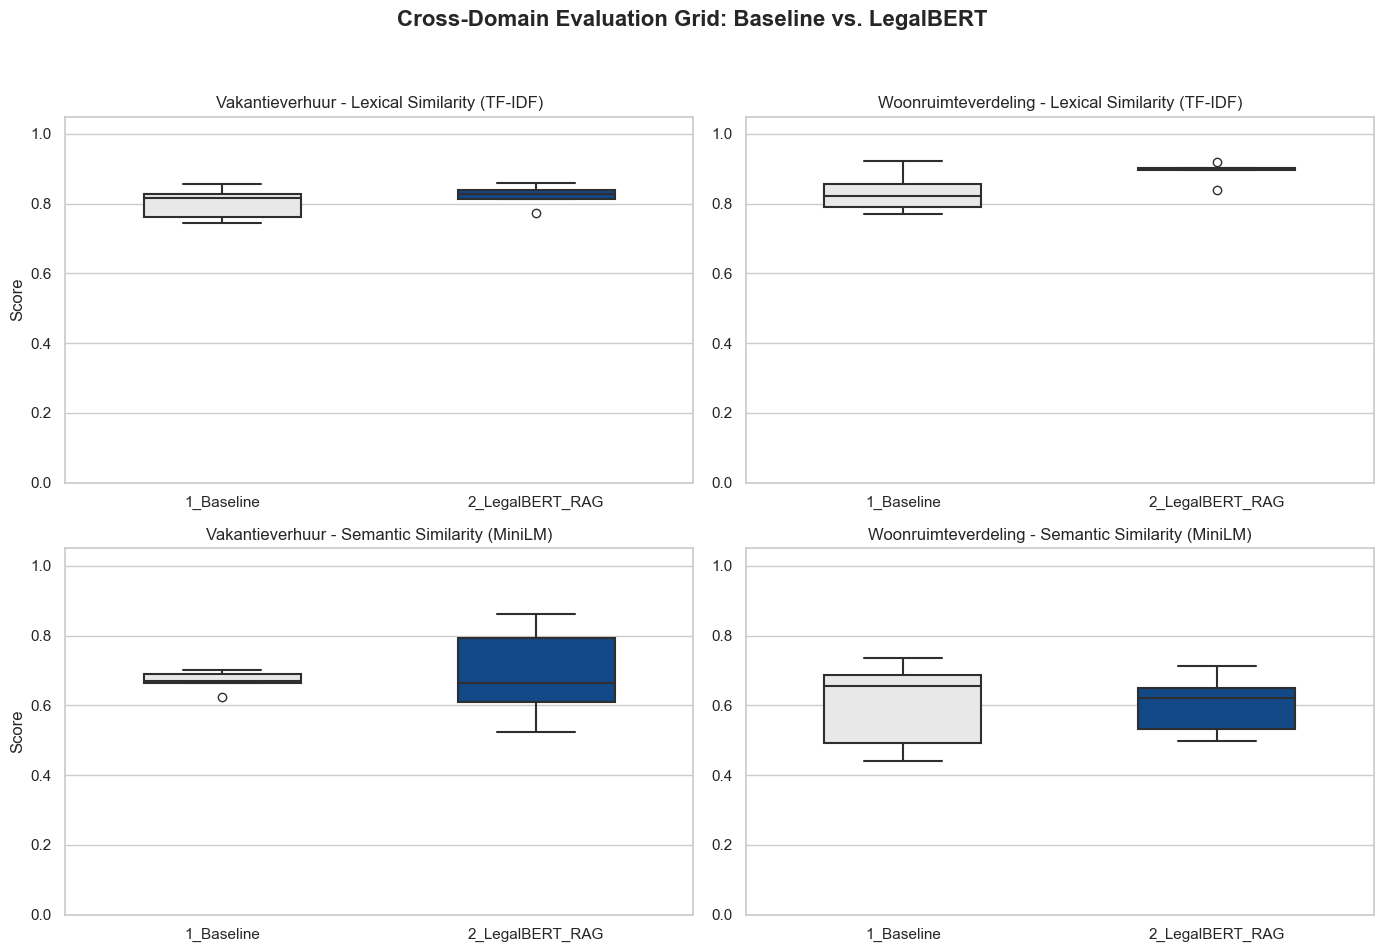

In [122]:
def plot_cross_domain_boxplot(df_metrics):
    sns.set_theme(style="whitegrid")

    palette = {
        "1_Baseline": "#e8e8e8",
        "2_LegalBERT_RAG": "#004699"
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Cross-Domain Evaluation Grid: Baseline vs. LegalBERT",
        fontsize=16,
        weight="bold",
        y=0.98
    )

    domains = ["Vakantieverhuur", "Woonruimteverdeling"]
    metrics = ["Lexical_TFIDF", "Semantic_BERT"]

    titles = {
        "Lexical_TFIDF": "Lexical Similarity (TF-IDF)",
        "Semantic_BERT": "Semantic Similarity (MiniLM)"
    }

    for row_idx, metric in enumerate(metrics):
        for col_idx, domain in enumerate(domains):
            ax = axes[row_idx, col_idx]
            subset = df_metrics[df_metrics["Domain"] == domain]

            sns.boxplot(
                data=subset,
                x="Model",
                y=metric,
                ax=ax,
                palette=palette,
                width=0.5,
                linewidth=1.5
            )

            ax.set_title(f"{domain} - {titles[metric]}", fontsize=12)
            ax.set_xlabel("")
            ax.set_ylabel("Score" if col_idx == 0 else "")
            ax.set_ylim(0, 1.05)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_path = "figures/cross_domain_boxplot.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"\nPlot saved successfully to: {save_path}")
    plt.show()


plot_cross_domain_boxplot(df_plot_data)

In [ ]:
os.makedirs("figures", exist_ok=True)

def generate_and_evaluate_models(N_cases=5):
    """
    Evalueert N cases op de testset en berekent de context-kwaliteit 
    op basis van de gelijkenis van de top-3 opgehaalde RAG-documenten.
    """
    records = []
    
    domains_config = {
        "Vakantieverhuur": {"test": df_v_testing, "bert": rag_v_bert},
        "Woonruimteverdeling": {"test": df_wrv_testing, "bert": rag_wrv_bert}
    }
    
    for domain, sys in domains_config.items():
        print(f"\nEvaluating domain: {domain}")
        if sys["test"].empty or "case_id" not in sys["test"].columns:
            continue
            
        case_ids = list(sys["test"]["case_id"].dropna().unique())
        random.seed(49)
        selected_cases = random.sample(case_ids, min(N_cases, len(case_ids)))
        
        for case_id in selected_cases:
            print(f"  - Processing case: {case_id}")
            row = sys["test"][sys["test"]["case_id"] == case_id].iloc[0]
            
            orig_letter = row.get("Legal_Text", "")
            bezwaar = row.get("chunk_bezwaar", "")
            hoorzitting = row.get("chunk_hoorzitting", "")
            dictum = row.get("dictum", "")
            
            meta = row.drop(labels=["Legal_Text", "chunk_uitleg", "geanonimiseerd_doc_inhoud"], errors="ignore").to_dict()
            
            retrieved_bert = sys["bert"].retrieve(query=bezwaar, top_k=3, dictum=dictum)
            
            retrieved_texts = [
                f"{c.get('chunk_wetten', '')} {c.get('chunk_uitleg', '')}" 
                for c in retrieved_bert
            ]
            context_bert = "\n".join(retrieved_texts)
            
            lex_retrieval_scores = []
            sem_retrieval_scores = []
            
            for text_chunk in retrieved_texts:
                if text_chunk.strip() and bezwaar.strip():
                    l_sim, s_sim = calculate_similarity_metrics(text_chunk, bezwaar)
                    lex_retrieval_scores.append(l_sim)
                    sem_retrieval_scores.append(s_sim)
            
            mean_retrieval_lex = np.mean(lex_retrieval_scores) if lex_retrieval_scores else 0.0
            mean_retrieval_sem = np.mean(sem_retrieval_scores) if sem_retrieval_scores else 0.0
            
            gen_baseline = generate_decision_letter(meta, bezwaar, hoorzitting, dictum, "", mode="baseline")
            gen_bert = generate_decision_letter(meta, bezwaar, hoorzitting, dictum, context_bert, mode="rag_standard")

            lex_base, sem_base = calculate_similarity_metrics(gen_baseline, orig_letter)
            lex_bert, sem_bert = calculate_similarity_metrics(gen_bert, orig_letter)
            
            records.append({
                "Domain": domain, "Case_ID": case_id, "Model": "1_Baseline", 
                "Retrieval_Lexical": 0.0, "Retrieval_Semantic": 0.0,
                "Letter_Lexical": lex_base, "Letter_Semantic": sem_base
            })
            
            records.append({
                "Domain": domain, "Case_ID": case_id, "Model": "2_LegalBERT_RAG", 
                "Retrieval_Lexical": mean_retrieval_lex, "Retrieval_Semantic": mean_retrieval_sem,
                "Letter_Lexical": lex_bert, "Letter_Semantic": sem_bert
            })
            
    return pd.DataFrame(records)

df_results_5_cases = generate_and_evaluate_models(N_cases=5)

summary_table = df_results_5_cases.groupby(["Domain", "Model"]).mean().round(4)
print(summary_table.to_string())


Evaluating domain: Vakantieverhuur
  - Processing case: JB.20.012188.001
  - Processing case: JB.24.008793.001
  - Processing case: JB.24.011103.001
  - Processing case: JB.20.014471.001
  - Processing case: JB.24.003487.001

Evaluating domain: Woonruimteverdeling
  - Processing case: WO.23.007232.001
  - Processing case: WO.24.002125.001
  - Processing case: WO.24.004038.001
  - Processing case: WO.23.008468.001
  - Processing case: WO.24.001032.001


TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
numeric_cols = ["Retrieval_Lexical", "Retrieval_Semantic", "Letter_Lexical", "Letter_Semantic"]
summary_table = df_results_5_cases.groupby(["Domain", "Model"])[numeric_cols].mean().round(4)

print(summary_table.to_string())

                                     Retrieval_Lexical  Retrieval_Semantic  Letter_Lexical  Letter_Semantic
Domain              Model                                                                                  
Vakantieverhuur     1_Baseline                  0.0000              0.0000          0.7966           0.7408
                    2_LegalBERT_RAG             0.6975              0.4965          0.8254           0.6956
Woonruimteverdeling 1_Baseline                  0.0000              0.0000          0.8437           0.6411
                    2_LegalBERT_RAG             0.5405              0.4547          0.8871           0.6332
